# AdaBoost 분류 실습 — 와인 품종 분류

**AdaBoost(Adaptive Boosting)** 는 얕은 결정 트리(약한 학습기)를 순차적으로 학습시키며, 이전 모델이 틀린 샘플의 가중치를 키워 다음 모델이 더 집중하도록 만드는 부스팅 기법입니다.

이 노트북에서는 사이킷런 내장 **와인(wine)** 데이터로 3가지 품종을 분류하고, 약한 학습기 개수(`n_estimators`)에 따른 성능 변화와 특성 중요도를 살펴봅니다.

## 목차
1. 라이브러리 임포트
2. 데이터 적재 및 분할
3. AdaBoost 모델 학습
4. 성능 평가
5. 약한 학습기 개수에 따른 성능 변화
6. 특성 중요도 확인

## 1. 라이브러리 임포트

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 그래프 한글 깨짐 방지 (Ubuntu: NanumGothic, 없으면 다른 한글 폰트로 변경)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. 데이터 적재 및 분할

와인 데이터는 13개의 수치형 특성(알코올, 색상 등 화학 성분)과 3개 품종 레이블(class_0, class_1, class_2)로 구성됩니다. 학습 80% / 테스트 20% 로 나누고, 클래스 비율을 유지하도록 `stratify` 를 적용합니다.

In [2]:
data = load_wine()
X, y = data.data, data.target

print('특성 개수:', X.shape[1])
print('샘플 개수:', X.shape[0])
print('클래스:', dict(zip(data.target_names, np.bincount(y))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('\n학습 샘플:', X_train.shape[0], '/ 테스트 샘플:', X_test.shape[0])

특성 개수: 13
샘플 개수: 178
클래스: {'class_0': 59, 'class_1': 71, 'class_2': 48}

학습 샘플: 142 / 테스트 샘플: 36


## 3. AdaBoost 모델 학습

약한 학습기로 **깊이 1짜리 결정 트리(decision stump)** 를 사용합니다. 이 단순한 모델을 `n_estimators=50` 개 순차적으로 학습하며, `learning_rate` 는 각 학습기의 기여도를 조절합니다.

> 사이킷런 1.2 이상에서는 `base_estimator` 대신 `estimator` 인자를 사용합니다.

In [3]:
stump = DecisionTreeClassifier(max_depth=1)

ada = AdaBoostClassifier(
    estimator=stump,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42,
)
ada.fit(X_train, y_train)
print('학습 완료:', ada)

학습 완료: AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   random_state=42)


## 4. 성능 평가

테스트셋에 대한 정확도, 분류 리포트(정밀도/재현율/F1), 혼동 행렬을 확인합니다.

In [4]:
y_pred = ada.predict(X_test)

print('정확도: {:.4f}\n'.format(accuracy_score(y_test, y_pred)))
print(classification_report(y_test, y_pred, target_names=data.target_names))

cm = confusion_matrix(y_test, y_pred)
print('혼동 행렬:')
print(pd.DataFrame(cm, index=data.target_names, columns=data.target_names))

정확도: 0.9167

              precision    recall  f1-score   support

     class_0       0.86      1.00      0.92        12
     class_1       0.92      0.86      0.89        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.92        36
   macro avg       0.93      0.92      0.92        36
weighted avg       0.92      0.92      0.92        36

혼동 행렬:
         class_0  class_1  class_2
class_0       12        0        0
class_1        2       12        0
class_2        0        1        9


## 5. 약한 학습기 개수에 따른 성능 변화

AdaBoost의 핵심 아이디어는 "약한 학습기를 많이 모으면 강해진다" 입니다. `n_estimators` 를 1부터 늘려가며 테스트 정확도가 어떻게 변하는지 그려봅니다.

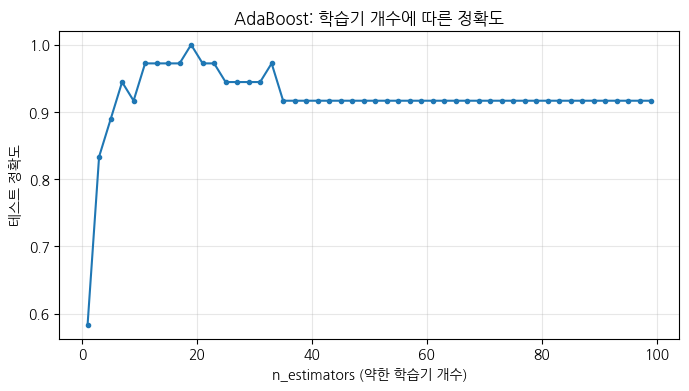

최고 정확도: 1.0000 (n_estimators=19)


In [5]:
n_range = range(1, 101, 2)
scores = []
for n in n_range:
    model = AdaBoostClassifier(estimator=stump, n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(list(n_range), scores, marker='o', markersize=3)
plt.xlabel('n_estimators (약한 학습기 개수)')
plt.ylabel('테스트 정확도')
plt.title('AdaBoost: 학습기 개수에 따른 정확도')
plt.grid(True, alpha=0.3)
plt.show()

print('최고 정확도: {:.4f} (n_estimators={})'.format(
    max(scores), list(n_range)[int(np.argmax(scores))]))

## 6. 특성 중요도 확인

AdaBoost는 각 약한 학습기가 사용한 특성의 기여도를 합산해 **특성 중요도** 를 제공합니다. 품종 분류에 가장 큰 영향을 준 상위 10개 특성을 살펴봅니다.

**계산식 (간단히):**

$$\text{특성 중요도} = \sum_t (\alpha_t \times \text{불순도 감소})$$

즉 각 학습기에서 그 특성이 만든 **불순도 감소량**에, 학습기 가중치 **$\alpha_t$** 를 곱해 전부 더한 값입니다.

**불순도 감소란?** 어떤 특성으로 데이터를 둘로 나눴을 때, 나누기 전보다 각 그룹이 얼마나 더 "한 품종으로 깔끔하게" 모였는지를 뜻합니다.

$$\text{불순도 감소} = G_{\text{부모}} - (G_{\text{왼쪽}} + G_{\text{오른쪽}})$$

- $G$ = 지니 불순도 (한 그룹에 여러 품종이 섞일수록 큼, 한 품종만 있으면 0)
- 나누기 전 지니에서, 나눈 뒤 왼쪽·오른쪽 지니를 뺀 값
- 잘 갈라주는 특성일수록 이 값이 커지고, 그만큼 중요도도 커집니다.

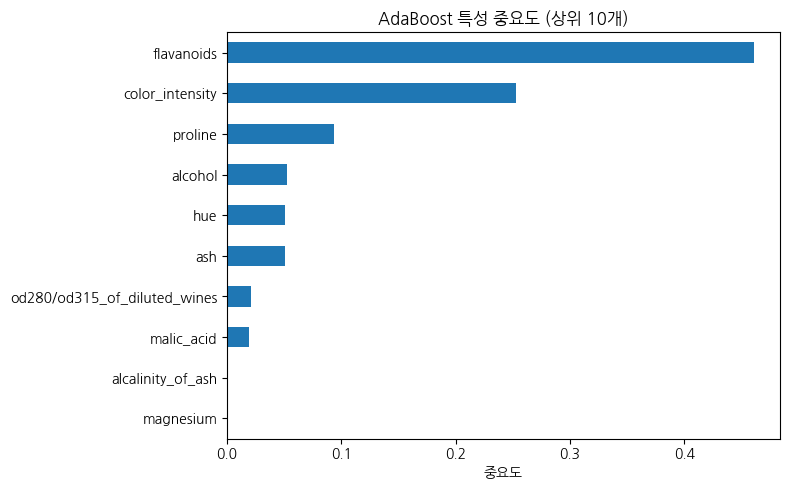

flavanoids                      0.460675
color_intensity                 0.252611
proline                         0.093847
alcohol                         0.052250
hue                             0.050884
ash                             0.050293
od280/od315_of_diluted_wines    0.020661
malic_acid                      0.018780
alcalinity_of_ash               0.000000
magnesium                       0.000000
dtype: float64

In [6]:
importances = pd.Series(ada.feature_importances_, index=data.feature_names)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10[::-1].plot(kind='barh')
plt.xlabel('중요도')
plt.title('AdaBoost 특성 중요도 (상위 10개)')
plt.tight_layout()
plt.show()

top10

## 정리

- **약한 학습기(stump)** 하나는 깊이 1짜리 트리로 성능이 낮지만, 부스팅으로 수십 개를 모으면 높은 정확도를 얻습니다.
- `n_estimators` 를 늘리면 일정 수준까지 정확도가 오르다가 수렴하며, 너무 크면 과적합/계산비용 증가가 나타날 수 있습니다.
- `learning_rate` 와 `n_estimators` 는 트레이드오프 관계로 함께 튜닝합니다.
- 특성 중요도로 어떤 변수가 분류에 기여했는지 해석할 수 있습니다.